# chinese_hackberry_bark — 训练轨迹与推理结果可视化

本 notebook 针对单个材质：
1. 从训练日志中提取并打印该材质 UC / BC / MLP 三阶段的 loss 曲线。
2. 加载对应 BC checkpoint，展示重建图像与参考图的对比。

所有图片直接 inline 显示，不保存到磁盘。

In [30]:
%matplotlib inline
import re
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

from ntc_bc_model import make_bc_model
from dataset import load_material
from ntc_utils import reconstruct_normal, compute_psnr


In [ ]:
MATERIAL = 'chinese_hackberry_bark'

CKPT_PATH = r'D:\ubisoftNTC\checkpoints\2026-06-10_145644\bc_bc1\chinese_hackberry_bark.pth'
LOG_PATH = 'logs/train_20260610_145620.log'
DATASET_ROOT = r'D:\ubisoftNTC\dataset\dataset'
BC_FORMAT = 'bc1'
TARGET_RES = 2048
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

MODEL_PARAMS = {
    'feature_configs': [(2048, 10, 3), (2048, 10, 3), (1024, 9, 3), (1024, 9, 3)],
    'hidden_dim': 16,
    'num_layers': 2,
    'filter': 'trilinear',
    'half_pixel_offsets': [],
}


In [32]:
LOG_RE = re.compile(
    r'^(?:\[\d+\]\s+)?'
    r'(?P<name>[\w_]+)\s+'
    r'(?P<stage>UC|BC|MLP)\s+'
    r'\[Iter\s+(?P<iter>\d+)/(?P<total>\d+)\]\s+'
    r'loss=(?P<loss>[\d.]+)\s+'
    r'avg_loss=(?P<avg_loss>[\d.]+)\s+'
    r'lr=(?P<lr>[\d.e+-]+)'
)

STAGE_COLORS = {'UC': '#2ca02c', 'BC': '#1f77b4', 'MLP': '#ff7f0e'}
STAGE_ORDER = ['UC', 'BC', 'MLP']

def parse_log(path):
    data = defaultdict(lambda: defaultdict(list))
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = LOG_RE.match(line.strip())
            if not m:
                continue
            name = m.group('name')
            stage = m.group('stage')
            it = int(m.group('iter'))
            loss = float(m.group('loss'))
            avg = float(m.group('avg_loss'))
            lr = float(m.group('lr'))
            data[name][stage].append((it, loss, avg, lr))
    return data


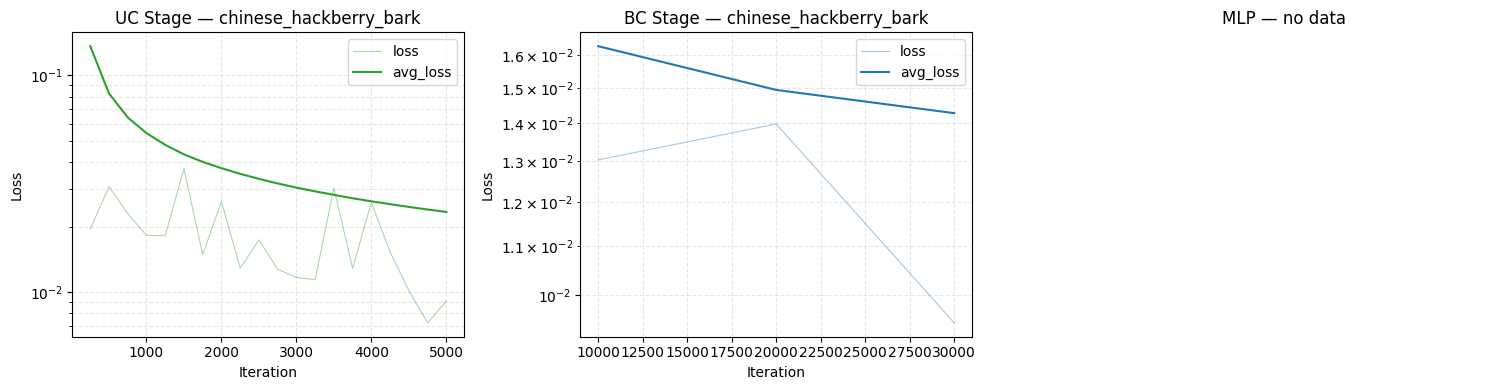

In [33]:
data = parse_log(LOG_PATH)
mat_data = data.get(MATERIAL)
if not mat_data:
    raise ValueError(f'在日志中未找到材质: {MATERIAL}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, stage in zip(axes, STAGE_ORDER):
    pts = mat_data.get(stage)
    if not pts:
        ax.set_title(f'{stage} — no data')
        ax.axis('off')
        continue
    pts.sort(key=lambda x: x[0])
    iters = [p[0] for p in pts]
    losses = [p[1] for p in pts]
    avgs = [p[2] for p in pts]
    ax.plot(iters, losses, label='loss', color=STAGE_COLORS[stage], alpha=0.4, linewidth=0.8)
    ax.plot(iters, avgs, label='avg_loss', color=STAGE_COLORS[stage], linewidth=1.5)
    ax.set_title(f'{stage} Stage — {MATERIAL}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()

In [34]:
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
state = ckpt['model_state_dict']

model = make_bc_model(MODEL_PARAMS, output_dim=9, bc_format_name=BC_FORMAT).to(DEVICE)
model.load_state_dict(state)
model.eval()

material_dir = os.path.join(DATASET_ROOT, MATERIAL)
ref = load_material(material_dir, target_res=TARGET_RES).to(DEVICE)

ref_albedo = ref[0:3].unsqueeze(0)
ref_normal = ref[3:6].unsqueeze(0)
ref_ao = ref[6:7].unsqueeze(0)
ref_rough = ref[7:8].unsqueeze(0)
ref_metal = ref[8:9].unsqueeze(0)

h, w = TARGET_RES, TARGET_RES
u = torch.linspace(0, 1, w, device=DEVICE)
v = torch.linspace(0, 1, h, device=DEVICE)
uv = torch.stack(torch.meshgrid(u, v, indexing='xy'), dim=-1).unsqueeze(0)

with torch.no_grad():
    pred = model(uv, torch.zeros(1, device=DEVICE))

pred_albedo = pred[:, 0:3]
pred_normal = reconstruct_normal(pred[:, 3:5])
pred_ao = pred[:, 6:7]
pred_rough = pred[:, 7:8]
pred_metal = pred[:, 8:9]

print(f'模型: {CKPT_PATH}')
print(f'设备: {DEVICE}')
print(f'输出 shape: {list(pred.shape)}')


模型: D:\ubisoftNTC\checkpoints\2026-06-10_145644\bc_bc1\chinese_hackberry_bark.pth
设备: cuda
输出 shape: [1, 9, 2048, 2048]


In [35]:
metrics = [
    ('Albedo', pred_albedo, ref_albedo),
    ('Normal', pred_normal, ref_normal),
    ('AO', pred_ao, ref_ao),
    ('Roughness', pred_rough, ref_rough),
    ('Metalness', pred_metal, ref_metal),
]

print(f"{'Channel':>12s}  {'PSNR (dB)':>10s}")
print('-' * 28)
for name, p, r in metrics:
    print(f"{name:>12s}  {compute_psnr(p, r):>10.2f}")
print('-' * 28)
print(f"{'Total':>12s}  {compute_psnr(pred, ref.unsqueeze(0)):>10.2f}")


     Channel   PSNR (dB)
----------------------------
      Albedo       33.02
      Normal       25.43
          AO       29.31
   Roughness       52.90
   Metalness       65.75
----------------------------
       Total       29.02


In [36]:
def tensor_to_numpy(t, is_normal=False):
    img = t.detach().cpu().permute(1, 2, 0).numpy()
    if is_normal:
        img = (img + 1.0) / 2.0
    return np.clip(img, 0, 1)

def show_pred_ref_diff(pred_t, ref_t, title='Channel', is_normal=False):
    p = tensor_to_numpy(pred_t, is_normal=is_normal)
    r = tensor_to_numpy(ref_t, is_normal=is_normal)
    diff = np.abs(p - r)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ['Predicted', 'Reference', 'Abs Diff']
    imgs = [p, r, diff]
    for ax, im, t in zip(axes, imgs, titles):
        if im.shape[-1] == 1:
            im = im[:, :, 0]
            cmap = 'gray'
        else:
            cmap = None
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()


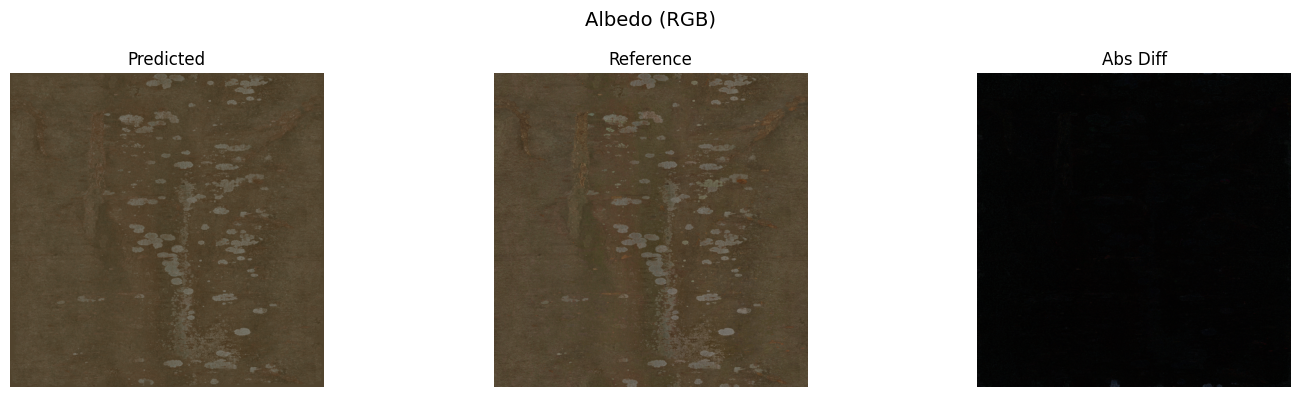

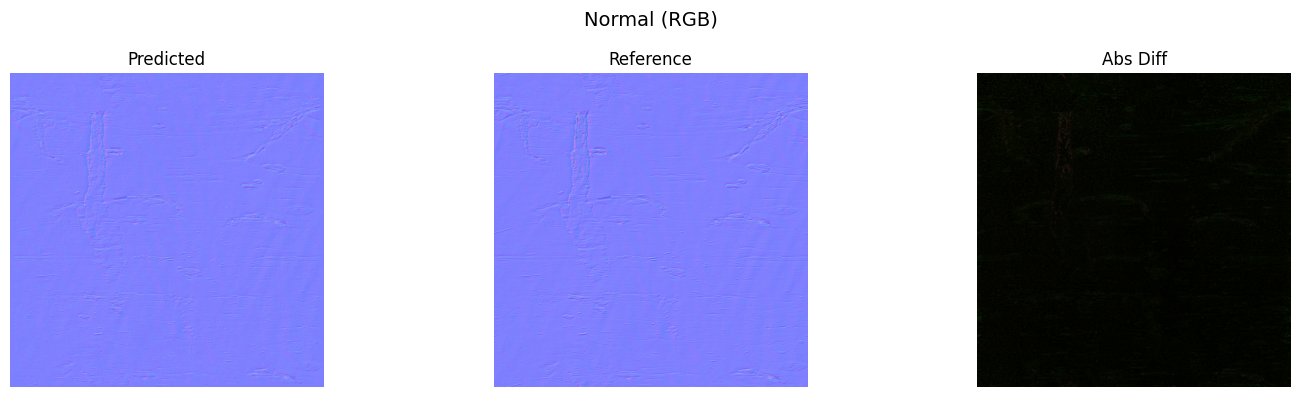

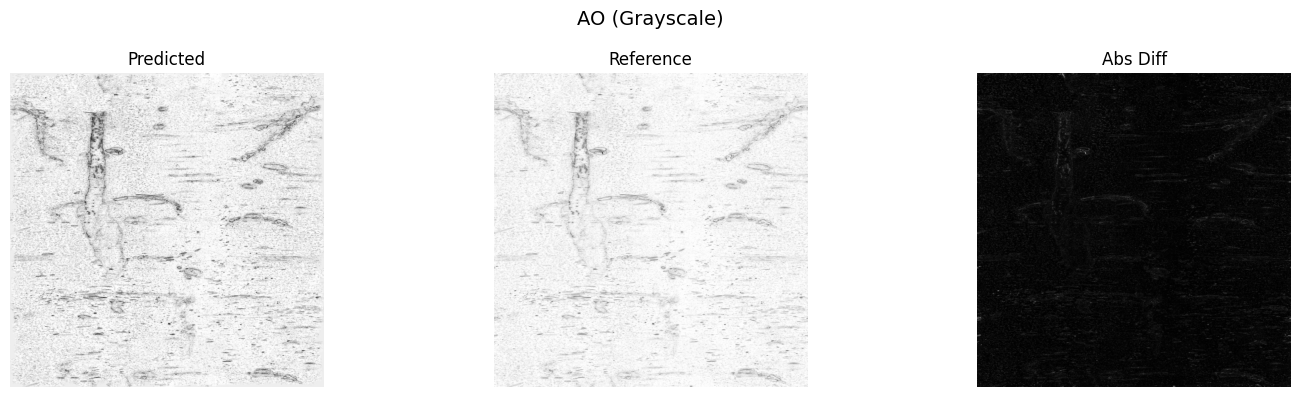

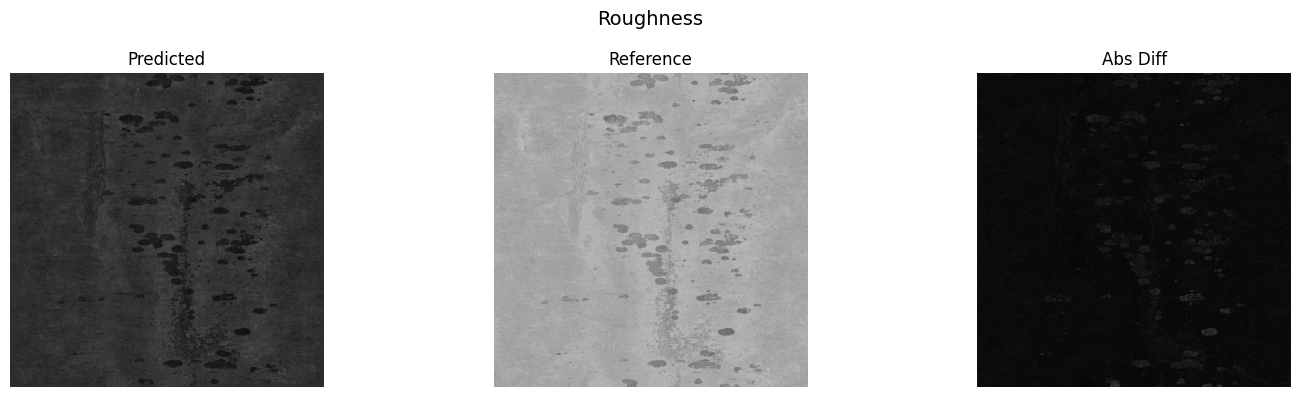

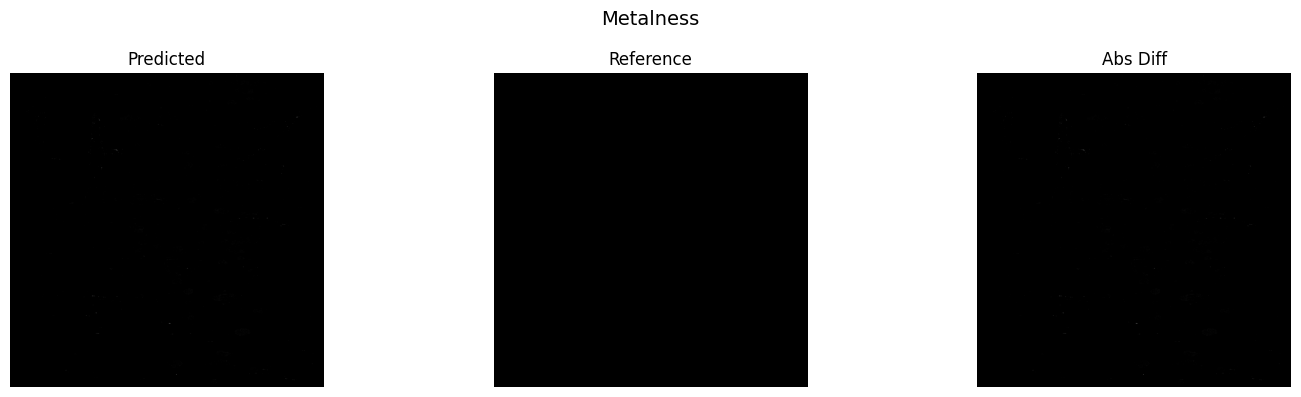

In [37]:
show_pred_ref_diff(pred_albedo[0], ref_albedo[0], title='Albedo (RGB)', is_normal=False)
show_pred_ref_diff(pred_normal[0], ref_normal[0], title='Normal (RGB)', is_normal=True)
show_pred_ref_diff(pred_ao[0], ref_ao[0], title='AO (Grayscale)', is_normal=False)
show_pred_ref_diff(pred_rough[0], ref_rough[0], title='Roughness', is_normal=False)
show_pred_ref_diff(pred_metal[0], ref_metal[0], title='Metalness', is_normal=False)


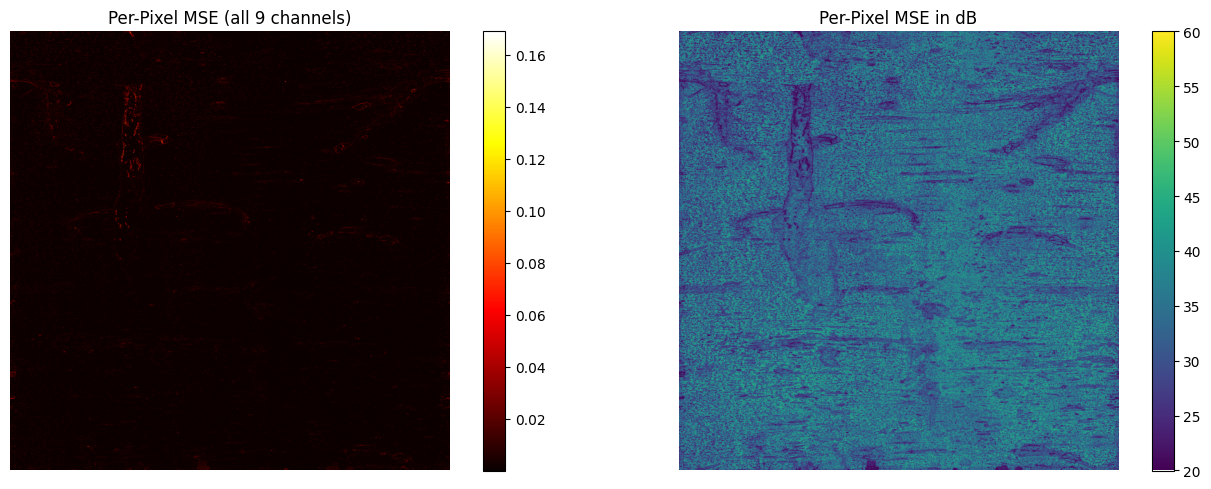

In [38]:
p = pred.detach().cpu()[0]
r = ref.detach().cpu()
mse_map = ((p - r) ** 2).mean(dim=0).numpy()
mse_db = -10 * np.log10(mse_map + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(mse_map, cmap='hot')
axes[0].set_title('Per-Pixel MSE (all 9 channels)')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mse_db, cmap='viridis', vmin=20, vmax=60)
axes[1].set_title('Per-Pixel MSE in dB')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()


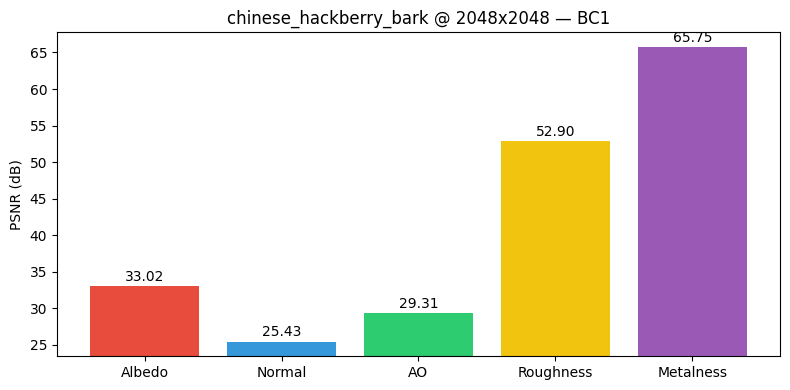

: 

In [ ]:
names = [m[0] for m in metrics]
psnrs = [compute_psnr(p, r) for _, p, r in metrics]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, psnrs, color=['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6'])
plt.ylabel('PSNR (dB)')
plt.title(f'{MATERIAL} @ {TARGET_RES}x{TARGET_RES} — BC1')
plt.ylim([min(psnrs) - 2, max(psnrs) + 2])
for bar, v in zip(bars, psnrs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
